# GéoMarketing IDF : J12 — Comparer et présélectionner des communes pour une étude d’implantation


## Objectifs

- Comparer les communes selon leur population et leur densité de restauration.

- Contextualiser les résultats avec les revenus, les emplois et les transports disponibles.

- Construire un indice exploratoire de présélection.

- Vérifier la sensibilité du classement à plusieurs pondérations.

- Cartographier les communes présélectionnées et préparer leurs fiches de synthèse.

- Préparer les analyses locales et les futures études à l’IRIS.

## Périmètre

Une comparaison à l’échelle communale en Île-de-France, centrée sur la restauration rapide, avec un examen spécifique de Cergy et Pontoise.

## Interprétation

- Les résultats permettent d’identifier les communes à approfondir pour une étude de marché et d’implantation.

- Le classement dépend des critères et des pondérations retenus. Une faible concurrence ne suffit pas à démontrer une demande ou une rentabilité. Les quartiers, les flux, les locaux et les loyers devront ensuite être étudiés.

In [1]:
#Import des librairies

import os
os.environ['OMP_NUM_THREADS'] = '1'
os.environ['NUMEXPR_NUM_THREADS'] = '1'
os.environ['MKL_NUM_THREADS'] = '1'

from pathlib import Path
from datetime import datetime, timezone
from html import escape
import hashlib
import json

import numpy as np
import pandas as pd
import geopandas as gpd
import plotly
import plotly.graph_objects as go
from IPython.display import display

pd.set_option('display.max_columns', 100)
pd.set_option('display.max_colwidth', 120)
CONFIG_PLOTLY = {'scrollZoom': True, 'displaylogo': False}
print('Pandas :', pd.__version__, 'GeoPandas :', gpd.__version__, 'Plotly :', plotly.__version__)


Pandas : 2.2.2 GeoPandas : 1.0.1 Plotly : 5.24.1


In [2]:
#Chemins

RACINE = Path(os.environ.get('GEOMARKETING_RACINE',
              r'C:\Users\almou\OneDrive\GeoMarketing_IDF'))
FICHIER_PROFIL_GEO = RACINE / 'data/processed/j11/profil_communes_idf_j11.gpkg'
COUCHE_COMMUNES = 'communes'
FICHIER_ARRETS = RACINE / 'data/processed/j11b/points_arret_idfm.gpkg'

DOSSIER_INTERIM = RACINE / 'data/interim/j12'
DOSSIER_PROCESSED = RACINE / 'data/processed/j12'
DOSSIER_CARTES = RACINE / 'outputs/cartes/j12'
for dossier in [DOSSIER_INTERIM, DOSSIER_PROCESSED, DOSSIER_CARTES]:
    dossier.mkdir(parents=True, exist_ok=True)
print('Profil de départ :', FICHIER_PROFIL_GEO)


Profil de départ : C:\Users\almou\OneDrive\GeoMarketing_IDF\data\processed\j11\profil_communes_idf_j11.gpkg


In [3]:
#Définir la question marketing et le périmètre

QUESTION_ETUDE = 'Quelles communes approfondir pour une restauration rapide de proximité ?'
CIBLE_CONCURRENCE = 'RAPIDE'  # RAPIDE, TRADITIONNELLE ou TOTAL
DEPARTEMENTS_ETUDE = []      # [] : tous les départements IDF du profil ; ['95'] : Val-d'Oise
POPULATION_MINIMALE = 5000
NOMBRE_COMMUNES_A_APPROFONDIR = 8
CODES_A_EXAMINER = ['95127', '95500']  # Cergy et Pontoise, si elles sont éligibles

SCENARIOS = {
    'REFERENCE_50_50': {'population': 0.50, 'concurrence': 0.50},
    'POPULATION_70_30': {'population': 0.70, 'concurrence': 0.30},
    'CONCURRENCE_30_70': {'population': 0.30, 'concurrence': 0.70},
}
SCENARIO_REFERENCE = 'REFERENCE_50_50'
DEPARTEMENTS_IDF = {'75', '77', '78', '91', '92', '93', '94', '95'}

if CIBLE_CONCURRENCE not in {'RAPIDE', 'TRADITIONNELLE', 'TOTAL'}:
    raise ValueError('CIBLE_CONCURRENCE incorrecte.')
if set(DEPARTEMENTS_ETUDE) - DEPARTEMENTS_IDF:
    raise ValueError('Le périmètre contient un département hors IDF.')
if POPULATION_MINIMALE < 0 or NOMBRE_COMMUNES_A_APPROFONDIR < 1:
    raise ValueError('Seuil de population ou taille de présélection incorrect.')
for nom, poids in SCENARIOS.items():
    if set(poids) != {'population', 'concurrence'}:
        raise ValueError(f'{nom} : critères incorrects.')
    if min(poids.values()) < 0 or not np.isclose(sum(poids.values()), 1):
        raise ValueError(f'{nom} : les poids doivent être positifs ou nuls et totaliser 1.')
if SCENARIO_REFERENCE not in SCENARIOS:
    raise ValueError('Scénario de référence absent.')
print(QUESTION_ETUDE)


Quelles communes approfondir pour une restauration rapide de proximité ?


In [4]:
#Fonctions de lecture et de contrôle

def normaliser_codes(serie):
    codes = (serie.astype('string').str.strip().str.upper()
             .str.replace(r'\.0$', '', regex=True))
    return codes.where(codes.str.fullmatch(r'\d{1,5}', na=False)).str.zfill(5)

def verifier_codes(table, nom):
    if 'CODGEO' not in table.columns:
        raise ValueError(f'{nom} : CODGEO absent. Colonnes : {table.columns.tolist()}')
    resultat = table.copy()
    resultat['CODGEO'] = normaliser_codes(resultat['CODGEO'])
    if resultat['CODGEO'].isna().any() or not resultat['CODGEO'].is_unique:
        raise ValueError(f'{nom} : codes communaux absents, invalides ou répétés.')
    return resultat

def normaliser_entetes(table):
    geometrie = table.geometry.name if isinstance(table, gpd.GeoDataFrame) else None
    resultat = table.rename(columns=lambda c: c if c == geometrie else str(c).strip().upper())
    if resultat.columns.duplicated().any():
        raise ValueError('Colonnes répétées après normalisation des entêtes.')
    return resultat

def nombres(serie):
    nettoye = (serie.astype('string').str.strip()
               .str.replace('\u202f', '', regex=False)
               .str.replace('\u00a0', '', regex=False)
               .str.replace(' ', '', regex=False)
               .str.replace(',', '.', regex=False))
    valeurs = pd.to_numeric(nettoye, errors='coerce').astype('Float64')
    return valeurs.where(np.isfinite(valeurs.to_numpy(dtype=float, na_value=np.nan)))

def est_renseigne(serie):
    marqueurs = {'', 'nan', 'none', '<na>', 'null', 'nd', '[nd]', '_z', '_u', 'n/a', '-'}
    texte = serie.astype('string').str.strip().str.casefold()
    return texte.notna() & ~texte.isin(marqueurs)

def exporter_csv(table, chemin):
    pd.DataFrame(table).to_csv(chemin, index=False, encoding='utf-8-sig')

def empreinte(chemin):
    h = hashlib.sha256()
    with Path(chemin).open('rb') as flux:
        for bloc in iter(lambda: flux.read(1024 * 1024), b''):
            h.update(bloc)
    return h.hexdigest()

def joindre_complement(profil, complement, colonnes, nom):
    complement = verifier_codes(normaliser_entetes(complement), nom)
    absentes = set(colonnes) - set(complement.columns)
    collisions = set(colonnes) & set(profil.columns)
    if absentes or collisions or 'CODGEO' in colonnes:
        raise ValueError(f'{nom} : champs absents {sorted(absentes)}, '
                         f'déjà présents {sorted(collisions)}. '
                         'Sélectionner les seuls champs utiles et les renommer si nécessaire.')
    non_apparies = complement.loc[~complement['CODGEO'].isin(profil['CODGEO']), ['CODGEO']]
    sortie = profil.merge(complement[['CODGEO'] + colonnes], on='CODGEO',
                          how='left', validate='one_to_one')
    if len(sortie) != len(profil):
        raise AssertionError('La jointure a modifié le nombre de communes.')
    return sortie, non_apparies


In [5]:
#Charger le profil géographique J11

if not FICHIER_PROFIL_GEO.is_file():
    raise FileNotFoundError(f'Profil J11 absent : {FICHIER_PROFIL_GEO}')
profil = gpd.read_file(FICHIER_PROFIL_GEO, layer=COUCHE_COMMUNES)
geom_original = profil.geometry.name
if geom_original != 'geometry':
    profil = profil.rename_geometry('geometry')
profil = normaliser_entetes(profil)
profil = verifier_codes(profil, 'Profil J11')
if profil.empty or profil.crs is None:
    raise ValueError('Profil vide ou système de coordonnées absent.')
valide = (profil.geometry.notna() & ~profil.geometry.is_empty & profil.geometry.is_valid
          & profil.geometry.geom_type.isin(['Polygon', 'MultiPolygon']))
if not valide.all():
    raise ValueError('Contours communaux invalides : reprendre les contrôles J11.')
profil = profil.to_crs(2154)
profil = profil[profil['CODGEO'].str[:2].isin(DEPARTEMENTS_IDF)].copy()
if profil.empty:
    raise ValueError('Aucune commune IDF dans le profil.')
if any(str(c).startswith('J12_') for c in profil.columns):
    raise ValueError('Le profil de départ contient déjà des résultats J12. Utiliser le profil J11.')
NOMBRE_COMMUNES_INITIAL = len(profil)
SOURCES_UTILISEES = [FICHIER_PROFIL_GEO]
print('Communes IDF disponibles :', len(profil))
print('Départements présents :', sorted(profil['CODGEO'].str[:2].unique()))
print('Colonnes disponibles :', profil.columns.tolist())
exporter_csv(pd.DataFrame({'COLONNE': profil.columns,
                           'TYPE': [str(profil[c].dtype) for c in profil.columns]}),
              DOSSIER_INTERIM / 'inventaire_colonnes_profil_j11.csv')


Communes IDF disponibles : 1266
Départements présents : ['75', '77', '78', '91', '92', '93', '94', '95']
Colonnes disponibles : ['CODGEO', 'NOM_COMMUNE_CONTOUR', 'NOM_COMMUNE', 'DEP', 'REG', 'POPULATION_2011', 'POPULATION_2016', 'POPULATION_2022', 'POP_0_14_ANS_2022', 'POP_15_29_ANS_2022', 'POP_30_44_ANS_2022', 'POP_45_59_ANS_2022', 'POP_60_74_ANS_2022', 'POP_75_89_ANS_2022', 'POP_90_ANS_PLUS_2022', 'POP_MOINS_30_ANS_2022', 'POP_15_44_ANS_2022', 'POP_60_ANS_PLUS_2022', 'POP_75_ANS_PLUS_2022', 'PART_0_14_ANS_PCT', 'PART_15_29_ANS_PCT', 'PART_30_44_ANS_PCT', 'PART_MOINS_30_ANS_PCT', 'PART_15_44_ANS_PCT', 'PART_60_ANS_PLUS_PCT', 'PART_75_ANS_PLUS_PCT', 'EVOLUTION_POP_2016_2022', 'EVOLUTION_POP_2016_2022_PCT', 'TAUX_ANNUEL_POP_2016_2022_PCT', 'REVENU_MEDIAN_EUROS', 'TAUX_PAUVRETE_PCT', 'EMPLOIS_SALARIES_LIEU_TRAVAIL', 'NOMBRE_ETABLISSEMENTS', 'EMPLOIS_SALARIES_POUR_100_HAB', 'ETABLISSEMENTS_POUR_1000_HAB', 'NB_RESTAURANTS_TOTAL', 'NB_RESTAURATION_RAPIDE', 'NB_RESTAURATION_TRADITIONNELLE', 

In [6]:
#Ajouter les revenus et emplois s'ils en manquent

COMPLEMENTS_PROFIL = [
    {'fichier': RACINE / 'data/processed/NOM_REEL_DU_FICHIER.csv',
     'colonnes': ['NIVEAU_VIE_MEDIAN_2023', 'EMPLOIS_AU_LIEU_DE_TRAVAIL']}
]

In [7]:
COMPLEMENTS_PROFIL = []

for numero, configuration in enumerate(COMPLEMENTS_PROFIL, start=1):
    fichier = Path(configuration['fichier'])
    if not fichier.is_file():
        raise FileNotFoundError(f'Complément absent : {fichier}')
    complement = pd.read_csv(fichier, sep=None, engine='python', dtype='string',
                             encoding='utf-8-sig')
    colonnes = [str(c).strip().upper() for c in configuration['colonnes']]
    profil, non_apparies = joindre_complement(profil, complement, colonnes, fichier.name)
    exporter_csv(non_apparies, DOSSIER_INTERIM / f'codes_complement_{numero}_non_apparies.csv')
    SOURCES_UTILISEES.append(fichier)
    print(fichier.name, ':', len(non_apparies), 'codes absents du profil communal')
assert len(profil) == NOMBRE_COMMUNES_INITIAL


In [14]:
#Choisir les colonnes réellement présentes

COLONNES_MANUELLES = {
    'population': None,
    'restaurants_total': None,
    'restaurants_rapides': None,
    'restaurants_traditionnels': None,
    'niveau_de_vie': None,
    'emplois_lieu_travail': None,
    'part_15_29_ans': None,
    'densite_alimentaires': None,
    'densite_culture': None,
}
DEFINITIONS = {
    'population': {'candidats': ['POPULATION_2022'],
                   'sortie': 'J12_POPULATION', 'unite': 'habitants (définition à vérifier)', 'type': 'nombre'},
    'restaurants_total': {'candidats': ['NB_RESTAURANTS_TOTAL', 'NB_OBS_RESTAURATION_TOTAL',
                                      'NB_OBS_RESTAURATION_A504', 'NB_OBS_RESTAURANTS_A504'],
                   'sortie': 'J12_NB_RESTAURANTS_TOTAL', 'unite': 'observations BPE A504', 'type': 'comptage'},
    'restaurants_rapides': {'candidats': ['NB_RESTAURATION_RAPIDE', 'NB_OBS_RESTAURATION_RAPIDE'],
                   'sortie': 'J12_NB_RESTAURATION_RAPIDE', 'unite': 'observations classées rapides', 'type': 'comptage'},
    'restaurants_traditionnels': {'candidats': ['NB_RESTAURATION_TRADITIONNELLE', 'NB_OBS_RESTAURATION_TRADITIONNELLE'],
                   'sortie': 'J12_NB_RESTAURATION_TRADITIONNELLE', 'unite': 'observations classées traditionnelles', 'type': 'comptage'},
    'niveau_de_vie': {'candidats': ['NIVEAU_VIE_MEDIAN_2023'],
                   'sortie': 'J12_NIVEAU_VIE_MEDIAN', 'unite': '€/an par unité de consommation, à vérifier', 'type': 'nombre'},
    'emplois_lieu_travail': {'candidats': ['EMPLOIS_15P_LT'],
                   'sortie': 'J12_EMPLOIS_LIEU_TRAVAIL', 'unite': 'emplois au lieu de travail', 'type': 'nombre'},
    'part_15_29_ans': {'candidats': ['PART_15_29_ANS_PCT'],
                   'sortie': 'J12_PART_15_29_ANS_PCT', 'unite': '% de la population, à vérifier', 'type': 'pourcentage'},
    'densite_alimentaires': {'candidats': ['DENSITE_OBS_ALIMENTAIRES_B2_10000_HAB'],
                   'sortie': 'J12_DENSITE_ALIMENTAIRES_10000_HAB', 'unite': 'observations / 10 000 habitants', 'type': 'nombre'},
    'densite_culture': {'candidats': ['DENSITE_OBS_CULTURE_10000_HAB'],
                   'sortie': 'J12_DENSITE_CULTURE_10000_HAB', 'unite': 'observations / 10 000 habitants', 'type': 'nombre'},
}
correspondance = {}
lignes_correspondance = []
problemes_colonnes = []
obligatoires = {'population', 'restaurants_total'}
if CIBLE_CONCURRENCE != 'TOTAL':
    obligatoires.add('restaurants_rapides' if CIBLE_CONCURRENCE == 'RAPIDE'
                     else 'restaurants_traditionnels')
for variable, definition in DEFINITIONS.items():
    manuel = COLONNES_MANUELLES[variable]
    candidats = [c for c in definition['candidats'] if c in profil.columns]
    if manuel:
        choisi = str(manuel).strip().upper()
        if choisi not in profil.columns:
            problemes_colonnes.append(f'{variable} : {choisi} absent.')
            choisi = None
    elif len(candidats) == 1:
        choisi = candidats[0]
    elif len(candidats) > 1:
        choisi = None
        problemes_colonnes.append(f'{variable} : choisir parmi {candidats} dans COLONNES_MANUELLES.')
    else:
        choisi = None
    correspondance[variable] = choisi
    if variable in obligatoires and choisi is None:
        problemes_colonnes.append(f'{variable} : champ obligatoire à renseigner au bloc 8.')
    lignes_correspondance.append({'VARIABLE': variable, 'COLONNE_SOURCE': choisi,
        'COLONNE_J12': definition['sortie'], 'UNITE_A_VERIFIER': definition['unite'],
        'OBLIGATOIRE': variable in obligatoires, 'ETAT': 'PRESENT' if choisi else 'ABSENT'})
table_correspondance = pd.DataFrame(lignes_correspondance)
display(table_correspondance)
exporter_csv(table_correspondance, DOSSIER_INTERIM / 'correspondance_variables_j12.csv')
if problemes_colonnes:
    raise ValueError('\n'.join(dict.fromkeys(problemes_colonnes)))


,VARIABLE,COLONNE_SOURCE,COLONNE_J12,UNITE_A_VERIFIER,OBLIGATOIRE,ETAT
0,population,POPULATION_2022,J12_POPULATION,habitants (définition à vérifier),True,PRESENT
1,restaurants_total,NB_RESTAURANTS_TOTAL,J12_NB_RESTAURANTS_TOTAL,observations BPE A504,True,PRESENT
2,restaurants_rapides,NB_RESTAURATION_RAPIDE,J12_NB_RESTAURATION_RAPIDE,observations classées rapides,True,PRESENT
3,restaurants_traditionnels,NB_RESTAURATION_TRADITIONNELLE,J12_NB_RESTAURATION_TRADITIONNELLE,observations classées traditionnelles,False,PRESENT
4,niveau_de_vie,NIVEAU_VIE_MEDIAN_2023,J12_NIVEAU_VIE_MEDIAN,"€/an par unité de consommation, à vérifier",False,PRESENT
5,emplois_lieu_travail,EMPLOIS_15P_LT,J12_EMPLOIS_LIEU_TRAVAIL,emplois au lieu de travail,False,PRESENT
6,part_15_29_ans,PART_15_29_ANS_PCT,J12_PART_15_29_ANS_PCT,"% de la population, à vérifier",False,PRESENT
7,densite_alimentaires,DENSITE_OBS_ALIMENTAIRES_B2_10000_HAB,J12_DENSITE_ALIMENTAIRES_10000_HAB,observations / 10 000 habitants,False,PRESENT
8,densite_culture,DENSITE_OBS_CULTURE_10000_HAB,J12_DENSITE_CULTURE_10000_HAB,observations / 10 000 habitants,False,PRESENT


In [15]:
#Compraer les valeurs et créer des champs de comparaison

controles_valeurs = []
anomalies = []
for variable, definition in DEFINITIONS.items():
    source = correspondance[variable]
    destination = definition['sortie']
    if source is None:
        profil[destination] = pd.Series(pd.NA, index=profil.index, dtype='Float64')
        continue
    original = profil[source]
    valeur = nombres(original)
    present = est_renseigne(original)
    non_numerique = present & valeur.isna()
    negative = valeur.lt(0).fillna(False)
    non_entier = (valeur.notna() & ~np.isclose(
        valeur.to_numpy(dtype=float, na_value=np.nan),
        np.round(valeur.to_numpy(dtype=float, na_value=np.nan)))) if definition['type'] == 'comptage' else pd.Series(False, index=profil.index)
    hors_plage = valeur.gt(100).fillna(False) if definition['type'] == 'pourcentage' else pd.Series(False, index=profil.index)
    invalide = non_numerique | negative | non_entier | hors_plage
    for index in profil.index[invalide]:
        anomalies.append({'CODGEO': profil.at[index, 'CODGEO'], 'VARIABLE': variable,
                          'COLONNE_SOURCE': source, 'VALEUR_SOURCE': str(original.loc[index])})
    profil[destination] = valeur
    controles_valeurs.append({'VARIABLE': variable, 'COLONNE_SOURCE': source,
        'NB_DISPONIBLES': int(valeur.notna().sum()), 'NB_MANQUANTS': int(valeur.isna().sum()),
        'NB_ANOMALIES': int(invalide.sum())})
controle_qualite = pd.DataFrame(controles_valeurs)
exporter_csv(controle_qualite, DOSSIER_INTERIM / 'controle_qualite_variables_j12.csv')
exporter_csv(pd.DataFrame(anomalies, columns=['CODGEO', 'VARIABLE', 'COLONNE_SOURCE', 'VALEUR_SOURCE']),
              DOSSIER_INTERIM / 'anomalies_valeurs_j12.csv')
display(controle_qualite)
if anomalies:
    raise ValueError('Des valeurs sont incohérentes. Examiner anomalies_valeurs_j12.csv avant de continuer.')
for colonne in ['J12_NB_RESTAURATION_RAPIDE', 'J12_NB_RESTAURATION_TRADITIONNELLE']:
    connu = profil[colonne].notna() & profil['J12_NB_RESTAURANTS_TOTAL'].notna()
    if (profil.loc[connu, colonne] > profil.loc[connu, 'J12_NB_RESTAURANTS_TOTAL']).any():
        raise ValueError('Un sous-type dépasse le nombre total de restaurants.')
sous_types_connus = (profil['J12_NB_RESTAURATION_RAPIDE'].notna()
                     & profil['J12_NB_RESTAURATION_TRADITIONNELLE'].notna()
                     & profil['J12_NB_RESTAURANTS_TOTAL'].notna())
if ((profil.loc[sous_types_connus, 'J12_NB_RESTAURATION_RAPIDE']
     + profil.loc[sous_types_connus, 'J12_NB_RESTAURATION_TRADITIONNELLE'])
    > profil.loc[sous_types_connus, 'J12_NB_RESTAURANTS_TOTAL']).any():
    raise ValueError('La somme rapide + traditionnelle dépasse le total : vérifier les catégories.')
noms = pd.Series(pd.NA, index=profil.index, dtype='string')
for colonne in ['NOM_COMMUNE_CONTOUR', 'NOM_COMMUNE', 'LIBELLE']:
    if colonne in profil.columns:
        noms = noms.fillna(profil[colonne].astype('string').str.strip().replace('', pd.NA))
profil['J12_NOM_COMMUNE'] = noms.fillna(profil['CODGEO'])


,VARIABLE,COLONNE_SOURCE,NB_DISPONIBLES,NB_MANQUANTS,NB_ANOMALIES
0,population,POPULATION_2022,1266,0,0
1,restaurants_total,NB_RESTAURANTS_TOTAL,1266,0,0
2,restaurants_rapides,NB_RESTAURATION_RAPIDE,1266,0,0
3,restaurants_traditionnels,NB_RESTAURATION_TRADITIONNELLE,1266,0,0
4,niveau_de_vie,NIVEAU_VIE_MEDIAN_2023,1252,14,0
5,emplois_lieu_travail,EMPLOIS_15P_LT,1266,0,0
6,part_15_29_ans,PART_15_29_ANS_PCT,1266,0,0
7,densite_alimentaires,DENSITE_OBS_ALIMENTAIRES_B2_10000_HAB,1266,0,0
8,densite_culture,DENSITE_OBS_CULTURE_10000_HAB,1266,0,0


In [16]:
#Calculer les indicateurs comparables

population_positive = profil['J12_POPULATION'].where(profil['J12_POPULATION'] > 0)
colonnes_cible = {'RAPIDE': 'J12_NB_RESTAURATION_RAPIDE',
                 'TRADITIONNELLE': 'J12_NB_RESTAURATION_TRADITIONNELLE',
                 'TOTAL': 'J12_NB_RESTAURANTS_TOTAL'}
COLONNE_COMPTE_CIBLE = colonnes_cible[CIBLE_CONCURRENCE]
profil['J12_NB_RESTAURANTS_CIBLE'] = profil[COLONNE_COMPTE_CIBLE]
profil['J12_DENSITE_RESTAURANTS_TOTAL_10000_HAB'] = (
    profil['J12_NB_RESTAURANTS_TOTAL'] / population_positive * 10000)
profil['J12_DENSITE_CONCURRENCE_CIBLE_10000_HAB'] = (
    profil['J12_NB_RESTAURANTS_CIBLE'] / population_positive * 10000)
total_positif = profil['J12_NB_RESTAURANTS_TOTAL'].where(profil['J12_NB_RESTAURANTS_TOTAL'] > 0)
profil['J12_PART_RESTAURATION_RAPIDE_PCT'] = (
    profil['J12_NB_RESTAURATION_RAPIDE'] / total_positif * 100)
profil['J12_EMPLOIS_POUR_100_HAB'] = (
    profil['J12_EMPLOIS_LIEU_TRAVAIL'] / population_positive * 100)
print('Concurrence étudiée :', CIBLE_CONCURRENCE)
display(profil[['CODGEO', 'J12_NOM_COMMUNE', 'J12_POPULATION',
    'J12_NB_RESTAURANTS_TOTAL', 'J12_NB_RESTAURANTS_CIBLE',
    'J12_DENSITE_CONCURRENCE_CIBLE_10000_HAB']].head(10))


Concurrence étudiée : RAPIDE


,CODGEO,J12_NOM_COMMUNE,J12_POPULATION,J12_NB_RESTAURANTS_TOTAL,J12_NB_RESTAURANTS_CIBLE,J12_DENSITE_CONCURRENCE_CIBLE_10000_HAB
0,75056,Paris,2113705.0,20911.0,8329.0,39.404742
1,77001,Achères-la-Forêt,1183.0,1.0,0.0,0.0
2,77002,Amillis,821.0,2.0,2.0,24.360536
3,77003,Amponville,351.0,1.0,0.0,0.0
4,77004,Andrezel,324.0,0.0,0.0,0.0
5,77005,Annet-sur-Marne,3329.0,6.0,2.0,6.00781
6,77006,Arbonne-la-Forêt,1007.0,5.0,2.0,19.860973
7,77007,Argentières,352.0,0.0,0.0,0.0
8,77008,Armentières-en-Brie,1196.0,0.0,0.0,0.0
9,77009,Arville,140.0,0.0,0.0,0.0


In [17]:
#Compter les points d'arrets obervés par commune

CHAMPS_ARRETS = {
    'TOTAL': 'J12_NB_POINTS_ARRET_OBSERVES',
    'BUS': 'J12_NB_POINTS_ARRET_BUS_OBSERVES',
    'FERROVIAIRE': 'J12_NB_POINTS_ARRET_FERROVIAIRES_OBSERVES',
    'AUTRE': 'J12_NB_POINTS_ARRET_AUTRE_MODE_OBSERVES',
}
for colonne in CHAMPS_ARRETS.values():
    profil[colonne] = pd.Series(pd.NA, index=profil.index, dtype='Float64')
profil['J12_SOURCE_ARRETS_DISPONIBLE'] = False
bilan_arrets = {'source_disponible': False}
if FICHIER_ARRETS.is_file():
    arrets = gpd.read_file(FICHIER_ARRETS)
    if arrets.geometry.name != 'geometry':
        arrets = arrets.rename_geometry('geometry')
    arrets = normaliser_entetes(arrets)
    requis = {'ID_ARRET_SOURCE', 'MODE_ARRET'}
    if requis - set(arrets.columns) or arrets.crs is None:
        raise ValueError('Arrêts J11b : identifiants, mode ou CRS manquants.')
    arrets['ID_ARRET_SOURCE'] = arrets['ID_ARRET_SOURCE'].astype('string').str.strip().replace('', pd.NA)
    if arrets['ID_ARRET_SOURCE'].isna().any() or not arrets['ID_ARRET_SOURCE'].is_unique:
        raise ValueError('Identifiants des points d’arrêt absents ou répétés.')
    valide = arrets.geometry.notna() & ~arrets.geometry.is_empty & arrets.geometry.is_valid & arrets.geometry.geom_type.eq('Point')
    if not valide.all():
        raise ValueError('Des points d’arrêt sont invalides : reprendre les contrôles J11b.')
    arrets = arrets.to_crs(2154)
    arrets['MODE_ARRET'] = arrets['MODE_ARRET'].astype('string').str.strip().str.upper()
    affectation = gpd.sjoin(arrets[['ID_ARRET_SOURCE', 'MODE_ARRET', 'geometry']],
        profil[['CODGEO', 'geometry']].rename(columns={'CODGEO': 'CODGEO_AFFECTE'}),
        how='left', predicate='within')
    multiples = affectation[affectation['ID_ARRET_SOURCE'].duplicated(keep=False)]
    exporter_csv(multiples.drop(columns='geometry'), DOSSIER_INTERIM / 'arrets_affectations_multiples.csv')
    if not multiples.empty:
        raise ValueError('Des points d’arrêt sont affectés à plusieurs communes : contrôler les contours.')
    sans_commune = affectation[affectation['CODGEO_AFFECTE'].isna()]
    exporter_csv(sans_commune.drop(columns='geometry'), DOSSIER_INTERIM / 'arrets_sans_commune_j12.csv')
    connus = affectation[affectation['CODGEO_AFFECTE'].notna()].copy()
    masques = {'TOTAL': pd.Series(True, index=connus.index),
              'BUS': connus['MODE_ARRET'].eq('BUS').fillna(False),
              'FERROVIAIRE': connus['MODE_ARRET'].eq('FERROVIAIRE').fillna(False),
              'AUTRE': ~connus['MODE_ARRET'].isin(['BUS', 'FERROVIAIRE'])}
    for categorie, destination in CHAMPS_ARRETS.items():
        comptes = connus.loc[masques[categorie]].groupby('CODGEO_AFFECTE')['ID_ARRET_SOURCE'].nunique()
        profil[destination] = profil['CODGEO'].map(comptes).fillna(0).astype('Int64')
    profil['J12_SOURCE_ARRETS_DISPONIBLE'] = True
    bilan_arrets = {'source_disponible': True, 'nb_points_source': len(arrets),
                   'nb_points_affectes': len(connus), 'nb_points_sans_commune': len(sans_commune)}
    SOURCES_UTILISEES.append(FICHIER_ARRETS)
    print(bilan_arrets)
else:
    print('Fichier d’arrêts absent : comparaison possible, métriques de transport manquantes.')


{'source_disponible': True, 'nb_points_source': 37956, 'nb_points_affectes': 37546, 'nb_points_sans_commune': 410}


In [18]:
#Définir les communes éligibles et expliquer les exclusions

raisons = pd.Series('', index=profil.index, dtype='string')
def ajouter_raison(masque, message):
    global raisons
    masque = masque.fillna(False)
    raisons.loc[masque] = raisons.loc[masque].map(lambda s: (s + ' ; ' if s else '') + message)
if DEPARTEMENTS_ETUDE:
    ajouter_raison(~profil['CODGEO'].str[:2].isin(DEPARTEMENTS_ETUDE), 'HORS_PERIMETRE')
ajouter_raison(profil['J12_POPULATION'].isna(), 'POPULATION_MANQUANTE')
ajouter_raison(profil['J12_POPULATION'].eq(0), 'POPULATION_NULLE')
ajouter_raison(profil['J12_POPULATION'].gt(0) & profil['J12_POPULATION'].lt(POPULATION_MINIMALE),
               'SOUS_SEUIL_POPULATION')
ajouter_raison(profil['J12_NB_RESTAURANTS_CIBLE'].isna(), 'CONCURRENCE_MANQUANTE')
profil['J12_RAISON_EXCLUSION'] = raisons
profil['J12_ELIGIBLE'] = raisons.eq('')
candidats = profil[profil['J12_ELIGIBLE']].copy()
exporter_csv(profil[['CODGEO', 'J12_NOM_COMMUNE', 'J12_ELIGIBLE', 'J12_RAISON_EXCLUSION']],
              DOSSIER_INTERIM / 'eligibilite_communes_j12.csv')
print('Communes éligibles :', len(candidats), '/', len(profil))
if len(candidats) < 2:
    raise ValueError('Moins de deux communes comparables : vérifier les données ou élargir le périmètre.')


Communes éligibles : 375 / 1266


In [22]:
#Calculer l'indice exploratoire et sa densité

def rang_percentile(serie, favorable_si_eleve):
    if serie.isna().any():
        raise ValueError('Le calcul des percentiles exige des valeurs complètes.')
    if len(serie) < 2 or serie.nunique() < 2:
        return pd.Series(50.0, index=serie.index)
    rangs = serie.rank(method='average', ascending=favorable_si_eleve)
    return (rangs - 1) / (len(serie) - 1) * 100

candidats['J12_CRITERE_POPULATION_0_100'] = rang_percentile(candidats['J12_POPULATION'], True)
candidats['J12_CRITERE_CONCURRENCE_0_100'] = rang_percentile(
    candidats['J12_DENSITE_CONCURRENCE_CIBLE_10000_HAB'], False)
scores = candidats[['CODGEO', 'J12_CRITERE_POPULATION_0_100', 'J12_CRITERE_CONCURRENCE_0_100']].copy()
colonnes_indices = []
colonnes_rangs = []
for nom, poids in SCENARIOS.items():
    indice = 'J12_INDICE_' + nom
    rang = 'J12_RANG_' + nom
    scores[indice] = (scores['J12_CRITERE_POPULATION_0_100'] * poids['population']
                      + scores['J12_CRITERE_CONCURRENCE_0_100'] * poids['concurrence'])
    scores[rang] = scores[indice].rank(method='min', ascending=False).astype('Int64')
    colonnes_indices.append(indice)
    colonnes_rangs.append(rang)
scores['J12_INDICE_PRESELECTION_EXPLORATOIRE'] = scores['J12_INDICE_' + SCENARIO_REFERENCE]
scores['J12_RANG_REFERENCE'] = scores['J12_RANG_' + SCENARIO_REFERENCE]
scores['J12_RANG_MIN_SCENARIOS'] = scores[colonnes_rangs].min(axis=1)
scores['J12_RANG_MAX_SCENARIOS'] = scores[colonnes_rangs].max(axis=1)
scores['J12_NB_SCENARIOS_DANS_PRESELECTION'] = scores[colonnes_rangs].le(
    NOMBRE_COMMUNES_A_APPROFONDIR).sum(axis=1)
profil = profil.merge(pd.DataFrame(scores), on='CODGEO', how='left', validate='one_to_one')
correlation = candidats[['J12_POPULATION', 'J12_DENSITE_CONCURRENCE_CIBLE_10000_HAB']].corr(method='spearman').iloc[0, 1]
print('Corrélation de rang population / densité :', correlation)
print('Indice exploratoire : aucun chiffre d’affaires ou potentiel commercial estimé.')


Corrélation de rang population / densité : 0.3282393901467744
Indice exploratoire : aucun chiffre d’affaires ou potentiel commercial estimé.


In [24]:
#Produire la présélection et les ajouts manuels

profil['J12_PRESELECTION_REFERENCE'] = profil['J12_RANG_REFERENCE'].le(
    NOMBRE_COMMUNES_A_APPROFONDIR).fillna(False)
profil['J12_AJOUT_MANUEL'] = (profil['CODGEO'].isin(CODES_A_EXAMINER)
                            & profil['J12_ELIGIBLE'] & ~profil['J12_PRESELECTION_REFERENCE'])
profil['J12_PRESELECTION_FINALE'] = profil['J12_PRESELECTION_REFERENCE'] | profil['J12_AJOUT_MANUEL']
profil['J12_ORIGINE_SELECTION'] = 'NON_PRESELECTIONNEE'
profil.loc[~profil['J12_ELIGIBLE'], 'J12_ORIGINE_SELECTION'] = 'NON_ELIGIBLE'
profil.loc[profil['J12_PRESELECTION_REFERENCE'], 'J12_ORIGINE_SELECTION'] = 'REFERENCE'
profil.loc[profil['J12_AJOUT_MANUEL'], 'J12_ORIGINE_SELECTION'] = 'AJOUT_MANUEL'
preselection = profil[profil['J12_PRESELECTION_FINALE']].sort_values(
    ['J12_RANG_REFERENCE', 'CODGEO']).copy()
codes_absents = sorted(set(CODES_A_EXAMINER) - set(profil['CODGEO']))
manuelles_exclues = profil[profil['CODGEO'].isin(CODES_A_EXAMINER) & ~profil['J12_ELIGIBLE']]
print('Communes à approfondir :', len(preselection))
print('Codes demandés mais absents du profil :', codes_absents)
if not manuelles_exclues.empty:
    display(manuelles_exclues[['CODGEO', 'J12_NOM_COMMUNE', 'J12_RAISON_EXCLUSION']])
COLONNES_COMPARAISON = ['CODGEO', 'J12_NOM_COMMUNE', 'J12_ORIGINE_SELECTION',
    'J12_POPULATION', 'J12_NB_RESTAURANTS_TOTAL', 'J12_NB_RESTAURANTS_CIBLE',
    'J12_DENSITE_CONCURRENCE_CIBLE_10000_HAB', 'J12_NIVEAU_VIE_MEDIAN',
    'J12_EMPLOIS_LIEU_TRAVAIL', 'J12_EMPLOIS_POUR_100_HAB', 'J12_PART_15_29_ANS_PCT',
    'J12_NB_POINTS_ARRET_BUS_OBSERVES', 'J12_NB_POINTS_ARRET_FERROVIAIRES_OBSERVES',
    'J12_INDICE_PRESELECTION_EXPLORATOIRE', 'J12_RANG_REFERENCE',
    'J12_RANG_MIN_SCENARIOS', 'J12_RANG_MAX_SCENARIOS', 'J12_NB_SCENARIOS_DANS_PRESELECTION']
display(preselection[COLONNES_COMPARAISON])


Communes à approfondir : 10
Codes demandés mais absents du profil : []


,CODGEO,J12_NOM_COMMUNE,J12_ORIGINE_SELECTION,J12_POPULATION,J12_NB_RESTAURANTS_TOTAL,J12_NB_RESTAURANTS_CIBLE,J12_DENSITE_CONCURRENCE_CIBLE_10000_HAB,J12_NIVEAU_VIE_MEDIAN,J12_EMPLOIS_LIEU_TRAVAIL,J12_EMPLOIS_POUR_100_HAB,J12_PART_15_29_ANS_PCT,J12_NB_POINTS_ARRET_BUS_OBSERVES,J12_NB_POINTS_ARRET_FERROVIAIRES_OBSERVES,J12_INDICE_PRESELECTION_EXPLORATOIRE,J12_RANG_REFERENCE,J12_RANG_MIN_SCENARIOS,J12_RANG_MAX_SCENARIOS,J12_NB_SCENARIOS_DANS_PRESELECTION
982,92048,Meudon,REFERENCE,46722.0,77.0,33.0,7.063054,34880.0,19421.41337,41.568027,16.87,118,13,88.101604,1,1,3,3
967,92019,Châtenay-Malabry,REFERENCE,35490.0,41.0,18.0,5.071851,31250.0,7859.30315,22.14512,18.86,102,0,87.967914,2,1,7,3
961,92002,Antony,REFERENCE,64026.0,139.0,63.0,9.839753,36480.0,22077.91092,34.482727,18.52,175,18,84.358289,3,1,12,2
986,92060,Le Plessis-Robinson,REFERENCE,28893.0,31.0,11.0,3.807151,35370.0,15655.95647,54.185984,16.38,89,0,84.224599,4,2,15,2
1018,93050,Neuilly-sur-Marne,REFERENCE,38799.0,62.0,34.0,8.763112,23160.0,9945.7683,25.634084,19.61,72,0,81.951872,5,5,10,2
993,92075,Vanves,REFERENCE,28507.0,61.0,17.0,5.963448,34820.0,7857.9497,27.564983,21.29,42,5,81.149733,6,5,28,2
560,78146,Chatou,REFERENCE,30054.0,56.0,22.0,7.320157,38150.0,6652.91466,22.136536,16.3,75,3,80.748663,7,7,18,2
1057,94046,Maisons-Alfort,REFERENCE,57422.0,128.0,61.0,10.623106,31480.0,17718.30392,30.856299,21.26,94,7,80.347594,8,4,38,2
1119,95127,Cergy,AJOUT_MANUEL,69578.0,218.0,144.0,20.696197,22560.0,36149.40782,51.955227,26.31,163,11,54.946524,160,57,261,0
1220,95500,Pontoise,AJOUT_MANUEL,31623.0,135.0,79.0,24.981817,24740.0,15087.50113,47.710531,22.61,93,11,41.310160,266,177,323,0


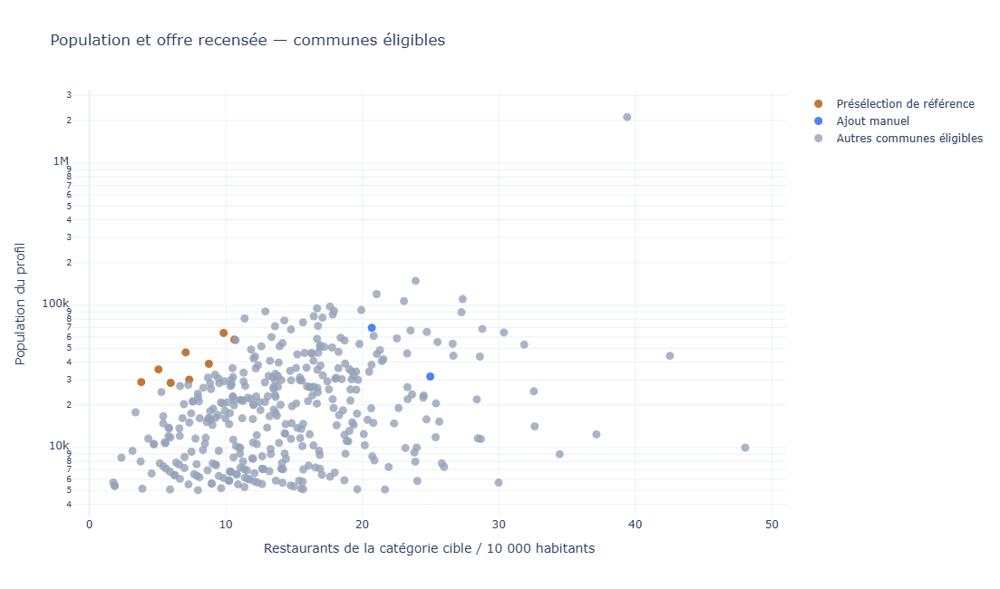

Graphique enregistré : C:\Users\almou\OneDrive\GeoMarketing_IDF\outputs\cartes\j12\01_population_concurrence_j12.html


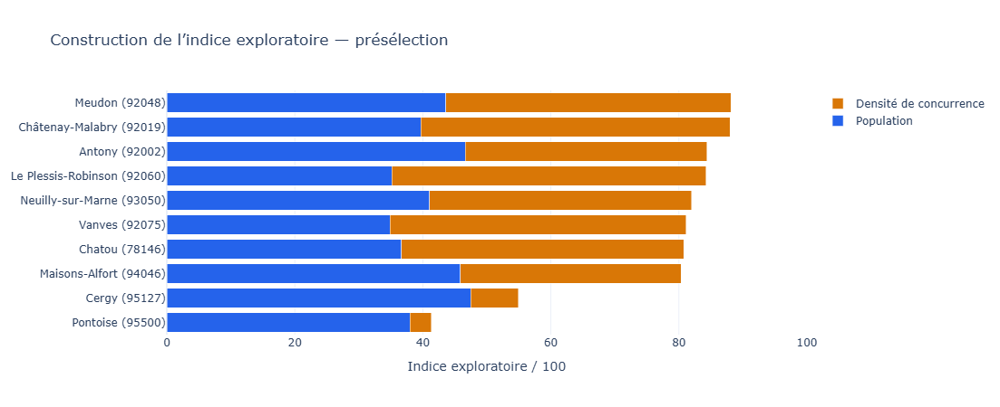

Graphique enregistré : C:\Users\almou\OneDrive\GeoMarketing_IDF\outputs\cartes\j12\02_contributions_indice_j12.html


In [25]:
#Graphique population / densité

def texte_valeur(valeur, decimales=1):
    if pd.isna(valeur):
        return 'Non disponible'
    return f'{float(valeur):,.{decimales}f}'.replace(',', ' ').replace('.', ',')

def afficher_exporter(fig, fichier):
    fig.write_html(str(fichier), include_plotlyjs=True, full_html=True, config=CONFIG_PLOTLY)
    fig.show(config=CONFIG_PLOTLY)
    print('Graphique enregistré :', fichier)

FIGURES_CREEES = []
FICHIERS_HTML = []
graphique = go.Figure()
groupes = [('REFERENCE', 'Présélection de référence', '#b45309'),
           ('AJOUT_MANUEL', 'Ajout manuel', '#2563eb'),
           ('NON_PRESELECTIONNEE', 'Autres communes éligibles', '#94a3b8')]
for statut, libelle, couleur in groupes:
    selection = profil[profil['J12_ELIGIBLE'] & profil['J12_ORIGINE_SELECTION'].eq(statut)]
    graphique.add_trace(go.Scatter(
        x=selection['J12_DENSITE_CONCURRENCE_CIBLE_10000_HAB'].to_numpy(dtype=float, na_value=np.nan),
        y=selection['J12_POPULATION'].to_numpy(dtype=float, na_value=np.nan),
        mode='markers', name=libelle, marker={'color': couleur, 'size': 9, 'opacity': 0.8},
        customdata=[[escape(str(r['J12_NOM_COMMUNE'])), str(r['CODGEO']),
                     texte_valeur(r['J12_NB_RESTAURANTS_CIBLE'], 0),
                     texte_valeur(r['J12_INDICE_PRESELECTION_EXPLORATOIRE'])]
                    for _, r in selection.iterrows()],
        hovertemplate='<b>%{customdata[0]}</b><br>Code : %{customdata[1]}'
            '<br>Population : %{y:,.0f}<br>Densité cible : %{x:.2f} / 10 000 hab.'
            '<br>Observations cible : %{customdata[2]}<br>Indice exploratoire : %{customdata[3]}'
            '<extra></extra>'))
graphique.update_layout(title='Population et offre recensée — communes éligibles',
    xaxis_title='Restaurants de la catégorie cible / 10 000 habitants',
    yaxis_title='Population du profil', yaxis_type='log', template='plotly_white', height=650)
sortie = DOSSIER_CARTES / '01_population_concurrence_j12.html'
afficher_exporter(graphique, sortie)
FIGURES_CREEES.append(graphique)
FICHIERS_HTML.append(sortie)

contributions = go.Figure()
poids = SCENARIOS[SCENARIO_REFERENCE]
labels = (preselection['J12_NOM_COMMUNE'] + ' (' + preselection['CODGEO'] + ')').tolist()
for critere, titre, couleur in [('population', 'Population', '#2563eb'),
                                ('concurrence', 'Densité de concurrence', '#d97706')]:
    champ = 'J12_CRITERE_' + critere.upper() + '_0_100'
    contributions.add_trace(go.Bar(name=titre, y=labels, orientation='h',
        x=(preselection[champ] * poids[critere]).to_numpy(dtype=float, na_value=np.nan),
        marker_color=couleur, hovertemplate='%{y}<br>Contribution : %{x:.1f} points<extra>%{fullData.name}</extra>'))
contributions.update_layout(title='Construction de l’indice exploratoire — présélection',
    barmode='stack', xaxis={'title': 'Indice exploratoire / 100', 'range': [0, 100]},
    yaxis={'autorange': 'reversed'}, template='plotly_white', height=max(450, len(preselection) * 32))
sortie = DOSSIER_CARTES / '02_contributions_indice_j12.html'
afficher_exporter(contributions, sortie)
FIGURES_CREEES.append(contributions)
FICHIERS_HTML.append(sortie)


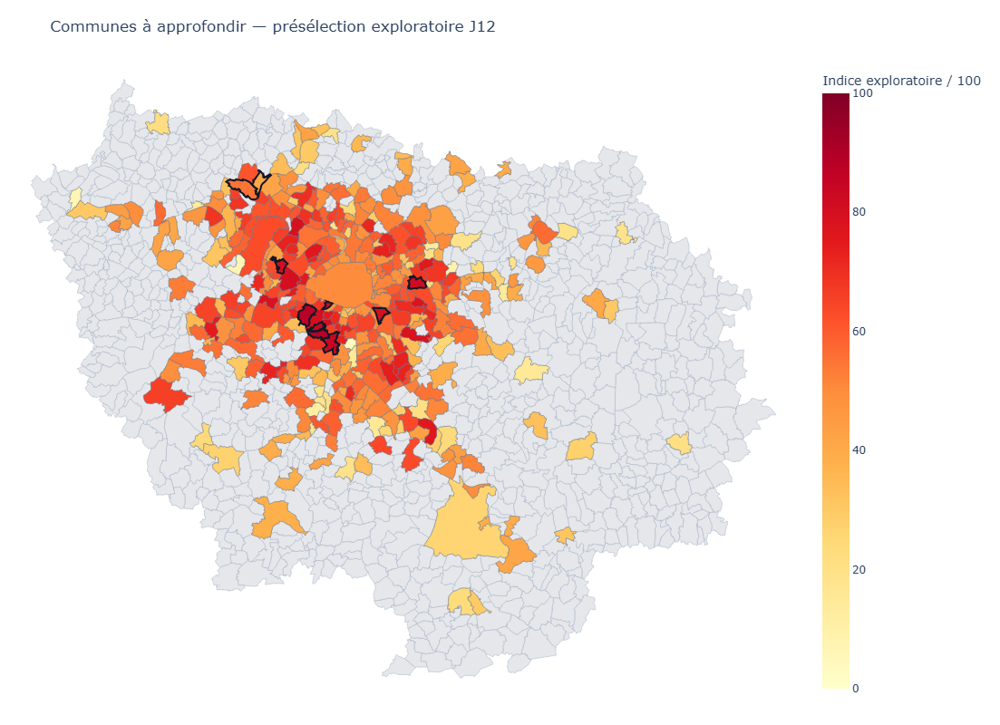

Graphique enregistré : C:\Users\almou\OneDrive\GeoMarketing_IDF\outputs\cartes\j12\03_carte_preselection_communes_j12.html


In [26]:
#Carte communale

def geojson_communes(table):
    geometrie = table[['CODGEO', 'geometry']].copy()
    geometrie.geometry = geometrie.geometry.simplify(20, preserve_topology=True)
    return json.loads(geometrie.to_crs(4326).to_json(na='null', drop_id=True))

carte = go.Figure()
carte.add_trace(go.Choropleth(geojson=geojson_communes(profil),
    locations=profil['CODGEO'].tolist(), featureidkey='properties.CODGEO',
    z=[0] * len(profil), zmin=0, zmax=1, colorscale=[[0, '#e5e7eb'], [1, '#e5e7eb']],
    showscale=False, showlegend=False, marker_line_color='#94a3b8', marker_line_width=0.4,
    text=[escape(str(n)) for n in profil['J12_NOM_COMMUNE']],
    customdata=[[str(r['J12_RAISON_EXCLUSION']) or 'Éligible'] for _, r in profil.iterrows()],
    hovertemplate='<b>%{text}</b><br>Code : %{location}<br>%{customdata[0]}<extra></extra>'))
eligibles = profil[profil['J12_ELIGIBLE']]
carte.add_trace(go.Choropleth(geojson=geojson_communes(eligibles),
    locations=eligibles['CODGEO'].tolist(), featureidkey='properties.CODGEO',
    z=eligibles['J12_INDICE_PRESELECTION_EXPLORATOIRE'].to_numpy(dtype=float, na_value=np.nan),
    zmin=0, zmax=100, colorscale='YlOrRd', showscale=True,
    colorbar={'title': {'text': 'Indice exploratoire / 100'}},
    marker_line_color='#64748b', marker_line_width=0.5,
    text=[escape(str(n)) for n in eligibles['J12_NOM_COMMUNE']],
    customdata=[[texte_valeur(r['J12_POPULATION'], 0),
                 texte_valeur(r['J12_DENSITE_CONCURRENCE_CIBLE_10000_HAB'], 2),
                 str(r['J12_ORIGINE_SELECTION'])] for _, r in eligibles.iterrows()],
    hovertemplate='<b>%{text}</b><br>Code : %{location}<br>Indice exploratoire : %{z:.1f}'
        '<br>Population : %{customdata[0]}<br>Densité cible : %{customdata[1]} / 10 000 hab.'
        '<br>Origine de sélection : %{customdata[2]}<extra></extra>'))
carte.add_trace(go.Choropleth(geojson=geojson_communes(preselection),
    locations=preselection['CODGEO'].tolist(), featureidkey='properties.CODGEO',
    z=[0] * len(preselection), zmin=0, zmax=1,
    colorscale=[[0, 'rgba(0,0,0,0)'], [1, 'rgba(0,0,0,0)']],
    showscale=False, showlegend=False, marker_line_color='#111827', marker_line_width=2,
    customdata=[[escape(str(r['J12_NOM_COMMUNE'])),
                 texte_valeur(r['J12_INDICE_PRESELECTION_EXPLORATOIRE']),
                 str(r['J12_ORIGINE_SELECTION'])] for _, r in preselection.iterrows()],
    hovertemplate='<b>%{customdata[0]}</b><br>Code : %{location}'
        '<br>Indice exploratoire : %{customdata[1]}<br>%{customdata[2]}<extra></extra>'))
xmin, ymin, xmax, ymax = profil.to_crs(4326).total_bounds
marge_x, marge_y = max((xmax - xmin) * 0.03, 0.001), max((ymax - ymin) * 0.03, 0.001)
carte.update_geos(visible=False, bgcolor='white', projection_type='mercator',
    center={'lon': (xmin + xmax) / 2, 'lat': (ymin + ymax) / 2},
    lonaxis={'range': [xmin - marge_x, xmax + marge_x]},
    lataxis={'range': [ymin - marge_y, ymax + marge_y]})
carte.update_layout(title='Communes à approfondir — présélection exploratoire J12',
    height=800, template='plotly_white', margin={'l': 10, 'r': 10, 't': 70, 'b': 30})
sortie = DOSSIER_CARTES / '03_carte_preselection_communes_j12.html'
afficher_exporter(carte, sortie)
FIGURES_CREEES.append(carte)
FICHIERS_HTML.append(sortie)


In [27]:
#Préparer une fiche de vérification par commune

fiches = pd.DataFrame(preselection[COLONNES_COMPARAISON]).copy()
fiches['FAITS_A_EXAMINER'] = [
    'Population du profil : ' + texte_valeur(r['J12_POPULATION'], 0)
    + ' ; observations de restaurants cible : ' + texte_valeur(r['J12_NB_RESTAURANTS_CIBLE'], 0)
    + ' ; densité cible : ' + texte_valeur(r['J12_DENSITE_CONCURRENCE_CIBLE_10000_HAB'], 2)
    + ' pour 10 000 habitants.' for _, r in fiches.iterrows()]
for colonne in ['ADEQUATION_CLIENTELE_OFFRE', 'QUARTIERS_IRIS_A_ETUDIER',
                'CONCURRENTS_DIRECTS_ET_POSITIONNEMENT', 'FLUX_ET_HORAIRES_A_VERIFIER',
                'LOCAUX_LOYERS_ET_CONTRAINTES', 'OBSERVATIONS_TERRAIN', 'DECISION_ARGUMENTEE']:
    fiches[colonne] = ''
fiches['STATUT_ETUDE'] = 'A_APPROFONDIR'
display(fiches[['CODGEO', 'J12_NOM_COMMUNE', 'FAITS_A_EXAMINER', 'STATUT_ETUDE']])


,CODGEO,J12_NOM_COMMUNE,FAITS_A_EXAMINER,STATUT_ETUDE
982,92048,Meudon,"Population du profil : 46 722 ; observations de restaurants cible : 33 ; densité cible : 7,06 pour 10 000 habitants.",A_APPROFONDIR
967,92019,Châtenay-Malabry,"Population du profil : 35 490 ; observations de restaurants cible : 18 ; densité cible : 5,07 pour 10 000 habitants.",A_APPROFONDIR
961,92002,Antony,"Population du profil : 64 026 ; observations de restaurants cible : 63 ; densité cible : 9,84 pour 10 000 habitants.",A_APPROFONDIR
986,92060,Le Plessis-Robinson,"Population du profil : 28 893 ; observations de restaurants cible : 11 ; densité cible : 3,81 pour 10 000 habitants.",A_APPROFONDIR
1018,93050,Neuilly-sur-Marne,"Population du profil : 38 799 ; observations de restaurants cible : 34 ; densité cible : 8,76 pour 10 000 habitants.",A_APPROFONDIR
993,92075,Vanves,"Population du profil : 28 507 ; observations de restaurants cible : 17 ; densité cible : 5,96 pour 10 000 habitants.",A_APPROFONDIR
560,78146,Chatou,"Population du profil : 30 054 ; observations de restaurants cible : 22 ; densité cible : 7,32 pour 10 000 habitants.",A_APPROFONDIR
1057,94046,Maisons-Alfort,"Population du profil : 57 422 ; observations de restaurants cible : 61 ; densité cible : 10,62 pour 10 000 habitants.",A_APPROFONDIR
1119,95127,Cergy,"Population du profil : 69 578 ; observations de restaurants cible : 144 ; densité cible : 20,70 pour 10 000 habitants.",A_APPROFONDIR
1220,95500,Pontoise,"Population du profil : 31 623 ; observations de restaurants cible : 79 ; densité cible : 24,98 pour 10 000 habitants.",A_APPROFONDIR


In [28]:
#Controles finaux, exports et provenance

assert len(profil) == NOMBRE_COMMUNES_INITIAL
assert profil['CODGEO'].is_unique and profil['CODGEO'].str.fullmatch(r'\d{5}').all()
assert preselection['CODGEO'].is_unique and not preselection.empty
assert profil.loc[profil['J12_ELIGIBLE'], 'J12_INDICE_PRESELECTION_EXPLORATOIRE'].between(0, 100).all()
assert profil.loc[~profil['J12_ELIGIBLE'], 'J12_INDICE_PRESELECTION_EXPLORATOIRE'].isna().all()
assert profil.loc[profil['J12_ELIGIBLE'], 'J12_NB_SCENARIOS_DANS_PRESELECTION'].between(0, len(SCENARIOS)).all()
if bilan_arrets['source_disponible']:
    assert (profil[CHAMPS_ARRETS['BUS']] + profil[CHAMPS_ARRETS['FERROVIAIRE']]
            + profil[CHAMPS_ARRETS['AUTRE']]).eq(profil[CHAMPS_ARRETS['TOTAL']]).all()
for fichier in FICHIERS_HTML:
    assert fichier.is_file() and fichier.stat().st_size > 0
assert carte.layout.geo.visible is False
assert all(t.type == 'choropleth' for t in carte.data)

FICHIER_PROFIL_J12 = DOSSIER_PROCESSED / 'profil_communes_idf_j12.csv'
FICHIER_PRESELECTION = DOSSIER_PROCESSED / 'preselection_communes_j12.csv'
FICHIER_FICHES = DOSSIER_PROCESSED / 'fiches_communes_a_approfondir_j12.csv'
FICHIER_SENSIBILITE = DOSSIER_PROCESSED / 'sensibilite_preselection_j12.csv'
FICHIER_CODES_IRIS = DOSSIER_PROCESSED / 'communes_pour_etude_iris_j12.csv'
FICHIER_GEO_SELECTION = DOSSIER_PROCESSED / 'preselection_communes_j12.gpkg'
exporter_csv(profil.drop(columns='geometry'), FICHIER_PROFIL_J12)
exporter_csv(preselection[COLONNES_COMPARAISON], FICHIER_PRESELECTION)
exporter_csv(fiches, FICHIER_FICHES)
exporter_csv(pd.DataFrame(scores), FICHIER_SENSIBILITE)
exporter_csv(preselection[['CODGEO', 'J12_NOM_COMMUNE', 'J12_ORIGINE_SELECTION']], FICHIER_CODES_IRIS)
geo_selection = preselection[['CODGEO', 'J12_NOM_COMMUNE', 'J12_ORIGINE_SELECTION',
                              'J12_INDICE_PRESELECTION_EXPLORATOIRE', 'geometry']].copy()
if FICHIER_GEO_SELECTION.exists():
    FICHIER_GEO_SELECTION.unlink()
geo_selection.to_file(FICHIER_GEO_SELECTION, layer='communes_preselection', driver='GPKG', index=False)

metadata = {
    'etape': 'J12_PRESELECTION_COMMUNALE',
    'date_execution_utc': datetime.now(timezone.utc).isoformat(),
    'question_etude': QUESTION_ETUDE, 'cible_concurrence': CIBLE_CONCURRENCE,
    'departements_etude': DEPARTEMENTS_ETUDE, 'population_minimale': POPULATION_MINIMALE,
    'nombre_communes_vise': NOMBRE_COMMUNES_A_APPROFONDIR, 'ex_aequo_conserves': True,
    'scenario_reference': SCENARIO_REFERENCE, 'scenarios': SCENARIOS,
    'nb_communes_profil': len(profil), 'nb_communes_reference': len(candidats),
    'codes_reference': sorted(candidats['CODGEO'].tolist()),
    'nb_communes_preselection': len(preselection), 'codes_manuels_demandes': CODES_A_EXAMINER,
    'correspondance_colonnes': correspondance, 'bilan_arrets': bilan_arrets,
    'fond_de_tuiles': False, 'cle_api_requise': False,
    'sources': [{'fichier': str(p), 'sha256': empreinte(p)} for p in dict.fromkeys(SOURCES_UTILISEES)],
    'logiciels': {'pandas': pd.__version__, 'geopandas': gpd.__version__, 'plotly': plotly.__version__},
    'limites': ['Indice exploratoire à deux critères, poids à adapter au cas client.',
                'Une faible concurrence ne suffit pas à établir une demande ou une rentabilité.',
                'Les points d’arrêt ne représentent pas les voyageurs, fréquences ou gares uniques.',
                'Millésimes et définition des variables doivent être vérifiés dans les sources.',
                'Les loyers, locaux disponibles, flux et quartiers restent à étudier.'],
}
(DOSSIER_PROCESSED / 'metadata_preselection_j12.json').write_text(
    json.dumps(metadata, ensure_ascii=False, indent=2), encoding='utf-8')
print('Profil enrichi :', FICHIER_PROFIL_J12)
print('Présélection :', FICHIER_PRESELECTION)
print('Fiches à compléter :', FICHIER_FICHES)
print('Communes pour le J13a IRIS :', FICHIER_CODES_IRIS)
print('J12 terminé : résultats à examiner avant validation commerciale.')


Profil enrichi : C:\Users\almou\OneDrive\GeoMarketing_IDF\data\processed\j12\profil_communes_idf_j12.csv
Présélection : C:\Users\almou\OneDrive\GeoMarketing_IDF\data\processed\j12\preselection_communes_j12.csv
Fiches à compléter : C:\Users\almou\OneDrive\GeoMarketing_IDF\data\processed\j12\fiches_communes_a_approfondir_j12.csv
Communes pour le J13a IRIS : C:\Users\almou\OneDrive\GeoMarketing_IDF\data\processed\j12\communes_pour_etude_iris_j12.csv
J12 terminé : résultats à examiner avant validation commerciale.
